# Урок 3. Первый разговор с моделью

🎯 **Цели урока**

- увидеть «сырой» HTTP-запрос и ответ OpenAI-совместимого API;
- работать с моделью через openai SDK: роли, история, лимиты;
- получить потоковый ответ и разобрать формат SSE;
- сравнить ответы с рассуждениями и без;
- заглянуть в tool calling, JSON Schema и эмбеддинги (подробно — в M10 и M11);
- оценить скорость и память модели и сверить оценки с реальностью.

📖 **Теория:** разделы «Модели: где живут и как с ними говорить» и «Скорость и память».

⏱ Ноутбук записан на моделях автора курса, ответы лежат в кассетах `./cassettes`. Повторный запуск
берёт их оттуда мгновенно. Чтобы увидеть ответы своих моделей, измените промпт или запустите
ноутбук с `LLM_CACHE=off`.

In [1]:
import json
import time

import mlcourse
from mlcourse import get_client, get_http_client, model_name, no_thinking, reasoning_text

print(mlcourse.describe_settings())

main   qwen3.8-27b  https://<удалённый сервер>/v1
local  qwen3:8b     http://localhost:11434/v1
embed  bge-m3       http://localhost:11434/v1
кэш    record       LLM_CACHE


## 1. Сырой HTTP-запрос

Никакой магии: запрос к модели — это обычный `POST` с JSON. `get_http_client("main")` возвращает
`httpx.Client` с адресом сервера и ключом из `.env`.

In [2]:
http = get_http_client("main")

body = {
    "model": model_name("main"),
    "messages": [{"role": "user", "content": "Объясни одним предложением, что такое токен в LLM."}],
    "max_tokens": 120,
    **no_thinking(),  # выключаем рассуждения: ответ быстрее и короче
}
response = http.post("chat/completions", json=body)
data = response.json()

print("HTTP", response.status_code)
print(json.dumps(data, ensure_ascii=False, indent=2))

HTTP 200
{
  "choices": [
    {
      "finish_reason": "stop",
      "index": 0,
      "message": {
        "role": "assistant",
        "content": "Токен в LLM — это базовая единица текста, которую модель обрабатывает (например, отдельное слово, часть слова или символ), соответствующая одному числу в её внутреннем векторном представлении."
      }
    }
  ],
  "created": 1790361471,
  "model": "qwen3.8-27b",
  "system_fingerprint": "b11028-972d2313b",
  "object": "chat.completion",
  "usage": {
    "completion_tokens": 49,
    "prompt_tokens": 28,
    "total_tokens": 77,
    "prompt_tokens_details": {
      "cached_tokens": 0
    }
  },
  "id": "chatcmpl-4vqfjImID64FoFBpjzRiSmDKkAChK7qu",
  "timings": {
    "cache_n": 0,
    "prompt_n": 28,
    "prompt_ms": 288.349,
    "prompt_per_token_ms": 10.29817857142857,
    "prompt_per_second": 97.1045503885916,
    "predicted_n": 49,
    "predicted_ms": 1669.272,
    "predicted_per_token_ms": 34.7765,
    "predicted_per_second": 28.7550501056

Главное в ответе:

- `choices[0].message.content` — текст ответа;
- `finish_reason` — почему модель остановилась (`stop` — сама закончила);
- `usage` — сколько токенов прочитано (`prompt_tokens`) и сгенерировано (`completion_tokens`).

Серверы добавляют и свои поля. Например, llama.cpp присылает `timings` — сколько длились фазы
prefill (`prompt_*`) и decode (`predicted_*`).

In [3]:
choice = data["choices"][0]
print("Ответ:        ", choice["message"]["content"])
print("finish_reason:", choice["finish_reason"])
print("usage:        ", data["usage"])
if timings := data.get("timings"):
    print(f"prefill: {timings['prompt_per_second']:.0f} ток/с, decode: {timings['predicted_per_second']:.1f} ток/с")

Ответ:         Токен в LLM — это базовая единица текста, которую модель обрабатывает (например, отдельное слово, часть слова или символ), соответствующая одному числу в её внутреннем векторном представлении.
finish_reason: stop
usage:         {'completion_tokens': 49, 'prompt_tokens': 28, 'total_tokens': 77, 'prompt_tokens_details': {'cached_tokens': 0}}
prefill: 97 ток/с, decode: 28.8 ток/с


## 2. То же самое через openai SDK

Писать JSON руками утомительно. Официальный SDK OpenAI работает с любым совместимым сервером,
если передать ему `base_url`, — `get_client()` делает это за нас.

In [4]:
client = get_client("main")

resp = client.chat.completions.create(
    model=model_name("main"),
    messages=[{"role": "user", "content": "Объясни одним предложением, что такое токен в LLM."}],
    max_tokens=120,
    extra_body=no_thinking(),  # параметры вне стандарта OpenAI передаются через extra_body
)
print(resp.choices[0].message.content)
print(resp.usage)

Токен в LLM — это базовая единица текста, которую модель обрабатывает (например, отдельное слово, часть слова или символ), соответствующая одному числу в её внутреннем векторном представлении.
CompletionUsage(completion_tokens=49, prompt_tokens=28, total_tokens=77, completion_tokens_details=None, prompt_tokens_details=PromptTokensDetails(audio_tokens=None, cache_write_tokens=None, cached_tokens=0, image_tokens=None, text_tokens=None))


Ответ совпал с предыдущим дословно, и это не случайность: SDK отправил **ровно тот же** JSON,
поэтому ответ взялся из кассеты. Кассета знает только тело запроса и ей всё равно, каким клиентом
он отправлен.

## 3. Роли и системный промпт

Системное сообщение задаёт поведение модели на весь диалог. Один и тот же вопрос — два разных стиля:

In [5]:
def ask(messages, role="main", **kwargs):
    """Отправить диалог модели и вернуть текст ответа (рассуждения выключены)."""
    r = get_client(role).chat.completions.create(
        model=model_name(role), messages=messages, extra_body=no_thinking(), **kwargs
    )
    return r.choices[0].message.content


question = {"role": "user", "content": "Что такое градиентный спуск?"}
for system in [
    "Ты — профессор математики. Отвечай строго и формально, в 2–3 предложениях.",
    "Ты объясняешь пятилетнему ребёнку. Одна-две простые фразы без терминов.",
]:
    print(f"🎭 {system}\n{ask([{'role': 'system', 'content': system}, question])}\n")

🎭 Ты — профессор математики. Отвечай строго и формально, в 2–3 предложениях.
Градиентный спуск — это итеративный алгоритм оптимизации, применяемый для поиска локального минимума гладкой функции. Его принцип основан на движении в направлении, противоположном вектору градиента, который указывает направление наибыстрейшего возрастания целевой функции.



🎭 Ты объясняешь пятилетнему ребёнку. Одна-две простые фразы без терминов.
Представь, что ты закрыл глаза и хочешь найти дно глубокой лужи.
Ты аккуратно шагаешь туда, где под ногами стало мокрее и ниже.



## 4. Модель ничего не помнит

API не хранит историю: каждый запрос самостоятелен. «Память» — это список `messages`,
который мы отправляем целиком каждый раз.

In [6]:
first = [{"role": "user", "content": "Меня зовут Алиса. Просто поздоровайся со мной."}]
greeting = ask(first)
print("Ответ на знакомство:", greeting)

print("\nБез истории:", ask([{"role": "user", "content": "Как меня зовут?"}]))

history = first + [
    {"role": "assistant", "content": greeting},
    {"role": "user", "content": "Как меня зовут?"},
]
print("С историей: ", ask(history))

Ответ на знакомство: Привет, Алиса! Рада познакомиться. Как ты поживешь?



Без истории: Меня не зовут, так как я — искусственный интеллект. У меня нет собственного имени в человеческом понимании, но вы можете обращаться ко мне как к вашему виртуальному помощнику или ассистенту.

А как вас зовут? Я буду рад, если вы поделитесь вашим именем, чтобы наша беседа стала более дружелюбной! 😊


С историей:  Тебя зовут Алиса.


## 5. Когда ответ обрезан: `finish_reason = "length"`

In [7]:
r = client.chat.completions.create(
    model=model_name("main"),
    messages=[{"role": "user", "content": "Перечисли через запятую 30 столиц мира."}],
    max_tokens=20,
    extra_body=no_thinking(),
)
print(repr(r.choices[0].message.content))
print("finish_reason:", r.choices[0].finish_reason)

'Москва, Берлин, Париж, Лондон, Мадрид, Рим, Афины'
finish_reason: length


Модель не «решила» остановиться, её оборвал лимит `max_tokens`. В продакшне `length` почти всегда
означает ошибку: ответ неполный, JSON невалиден и т. п. Такие случаи нужно ловить явно.

## 6. Потоковая выдача: как выглядит SSE

С `"stream": true` сервер присылает ответ кусочками в формате Server-Sent Events. Посмотрим
на «сырые» строки потока:

In [8]:
with http.stream("POST", "chat/completions", json={**body, "stream": True}) as r:
    lines = list(r.iter_lines())

print(f"Строк в потоке: {len(lines)}. Начало:\n")
for line in lines[:6]:
    print(line[:160])
print("…\nКонец:", [line[:60] for line in lines[-3:]])

Строк в потоке: 88. Начало:

data: {"choices":[{"finish_reason":null,"index":0,"delta":{"role":"assistant","content":null}}],"created":1790361487,"id":"chatcmpl-vvKWDR8MRFn2LYqyrqCwBzNKSyU4

data: {"choices":[{"finish_reason":null,"index":0,"delta":{"content":"Т"}}],"created":1790361487,"id":"chatcmpl-vvKWDR8MRFn2LYqyrqCwBzNKSyU4qsv5","model":"qwen3

data: {"choices":[{"finish_reason":null,"index":0,"delta":{"content":"ок"}}],"created":1790361487,"id":"chatcmpl-vvKWDR8MRFn2LYqyrqCwBzNKSyU4qsv5","model":"qwen

…
Конец: ['', 'data: [DONE]', '']


Каждое событие — строка `data: {JSON}` и пустая строка-разделитель, в конце — `data: [DONE]`.
Кусочки ответа лежат в `choices[0].delta.content`. Разобрать такой поток — ваше упражнение `ex03`.

SDK делает разбор сам: при `stream=True` он возвращает итератор по событиям. Замерим время до
первого токена (TTFT) и скорость генерации у обеих моделей:

In [9]:
def measure(role: str, prompt: str, max_tokens: int = 200) -> dict:
    """Потоковый запрос: время до первого токена, общее время и число токенов."""
    t0, ttft, parts, usage = time.perf_counter(), None, [], None
    stream = get_client(role).chat.completions.create(
        model=model_name(role),
        messages=[{"role": "user", "content": prompt}],
        max_tokens=max_tokens,
        stream=True,
        stream_options={"include_usage": True},  # последним событием придёт статистика токенов
        extra_body=no_thinking(),
    )
    for chunk in stream:
        if chunk.usage:
            usage = chunk.usage
        if chunk.choices and chunk.choices[0].delta.content:
            ttft = ttft or time.perf_counter() - t0
            parts.append(chunk.choices[0].delta.content)
    total = time.perf_counter() - t0
    tokens = usage.completion_tokens if usage else len(parts)
    return {
        "role": role,
        "model": model_name(role),
        "from_cassette": stream.response.headers.get("x-mlcourse-cassette") == "hit",
        "ttft_s": ttft or 0.0,
        "total_s": total,
        "tokens": tokens,
        "text": "".join(parts),
    }


prompt = "Назови 10 рек России через запятую, без пояснений."
for m in [measure("main", prompt), measure("local", prompt)]:
    speed = m["tokens"] / max(m["total_s"] - m["ttft_s"], 1e-9)
    note = "  ← из кассеты: время не показательно" if m["from_cassette"] else ""
    print(f"{m['role']:<5} {m['model']:<12} TTFT {m['ttft_s']:5.2f} с | {m['tokens']:3d} ток. | {speed:6.1f} ток/с{note}")
    print(f"      {m['text'][:110]}")

main  qwen3.8-27b  TTFT  0.72 с |  35 ток. |   29.4 ток/с
      Волга, Обь, Енисей, Лена, Амур, Дон, Северная Двина, Печора, Тобол, Урал
local qwen3:8b     TTFT  6.11 с |  48 ток. |    7.6 ток/с
      Волга, Обь, Енисей, Лена, Северная Двина, Кама, Урал, Терек, Уссурийка, Иртыш.


При воспроизведении из кассеты время почти нулевое — в этом и смысл кэша. Честные замеры скорости,
которые сохраняются вместе с ответом, возьмём у самого сервера в разделе 9.

## 7. Думать или не думать

Qwen3 — рассуждающая модель: по умолчанию перед ответом она «думает вслух». Сравним один и тот же
вопрос в двух режимах:

In [10]:
puzzle = (
    "У Маши было 12 яблок. Она отдала треть Пете, а потом купила ещё 5. "
    "Сколько яблок у Маши? В ответе — только число."
)
for thinking in (False, True):
    t0 = time.perf_counter()
    r = client.chat.completions.create(
        model=model_name("main"),
        messages=[{"role": "user", "content": puzzle}],
        max_tokens=3000,
        extra_body={} if thinking else no_thinking(),
    )
    msg = r.choices[0].message
    reasoning = reasoning_text(msg)
    print(f"thinking={thinking!s:<5} ответ={msg.content.strip()!r:<6} "
          f"токенов ответа: {r.usage.completion_tokens:4d}, рассуждений: {len(reasoning):5d} символов")
    if reasoning:
        print("\nНачало рассуждений:\n", reasoning[:400].strip(), "…")

thinking=False ответ='11'   токенов ответа:    3, рассуждений:     0 символов


thinking=True  ответ='13'   токенов ответа:   72, рассуждений:   215 символов

Начало рассуждений:
 We need answer in Russian? User asks simple math, answer only number. Need compute: Masha had 12 apples. Gave away a third to Petya: 12/3=4, remaining 8. Then bought 5, total 13. Final only number. Ensure no extra. …


В записи автора курса без рассуждений модель **ошиблась** — ответила 11 вместо 13. Задача в два шага
(отдать треть, потом докупить), а ответ «с ходу» — это одна попытка угадать число. С рассуждениями
модель посчитала по шагам и ответила верно, но потратила в два десятка раз больше токенов. Заметьте
и то, что «думает» она по-английски, хотя вопрос русский.

Рассуждения — компромисс между качеством и временем. Когда они окупаются, а когда нет, будем
измерять на тестовых наборах в M07 и M09. В агентных циклах курса рассуждения по умолчанию выключены
ради скорости, а качество обеспечивается устройством самого цикла: разбиением задачи на шаги
и проверками.

## 8. Заглянем вперёд: инструменты и JSON

**Tool calling.** Модели описывают доступные функции, и вместо текста она может вернуть
*запрос на вызов* функции с аргументами. Выполнять функцию — задача нашего кода (M10).

In [11]:
tools = [{
    "type": "function",
    "function": {
        "name": "get_weather",
        "description": "Текущая погода в городе",
        "parameters": {
            "type": "object",
            "properties": {"city": {"type": "string", "description": "Название города"}},
            "required": ["city"],
        },
    },
}]
r = client.chat.completions.create(
    model=model_name("main"),
    messages=[{"role": "user", "content": "Нужен ли сегодня зонт в Казани?"}],
    tools=tools,
    extra_body=no_thinking(),
)
print("finish_reason:", r.choices[0].finish_reason)
for call in r.choices[0].message.tool_calls or []:
    print(f"модель просит вызвать {call.function.name}({call.function.arguments})")

finish_reason: tool_calls
модель просит вызвать get_weather({"city":"Казань"})


**JSON Schema.** Можно потребовать, чтобы ответ строго соответствовал схеме, — сервер ограничит
генерацию так, что невалидный JSON получиться не может (как это устроено — M10).

In [12]:
schema = {
    "type": "object",
    "properties": {
        "name": {"type": "string"},
        "age": {"type": "integer"},
        "skills": {"type": "array", "items": {"type": "string"}},
    },
    "required": ["name", "age", "skills"],
}
r = client.chat.completions.create(
    model=model_name("main"),
    messages=[{"role": "user", "content": "Извлеки данные: Анна Смирнова, 29 лет, пишет на Python и Go, знает SQL."}],
    response_format={"type": "json_schema", "json_schema": {"name": "person", "schema": schema}},
    extra_body=no_thinking(),
)
person = json.loads(r.choices[0].message.content)
print(person)

{'name': 'Анна Смирнова', 'age': 29, 'skills': ['Python', 'Go', 'SQL']}


**Эмбеддинги.** Модель эмбеддингов превращает текст в вектор так, что близкие по смыслу тексты
получают близкие векторы — даже на разных языках. Меру близости — косинус угла между векторами —
разберём в M01 и M11.

Размерность вектора: 1024


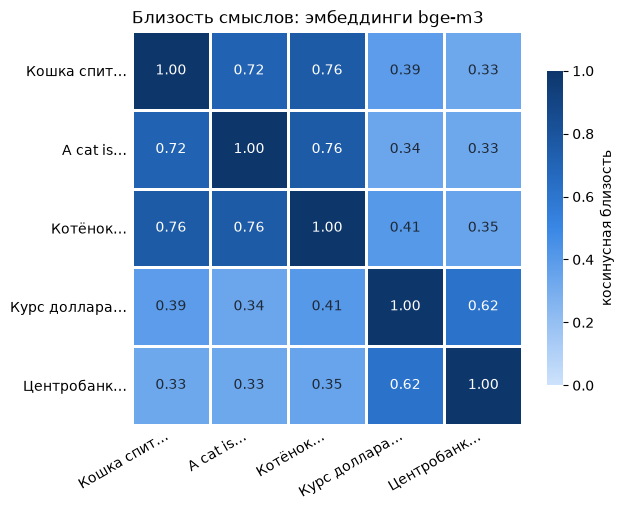

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

from mlcourse import embed

texts = [
    "Кошка спит на подоконнике",
    "A cat is sleeping on the windowsill",
    "Котёнок дремлет у окна",
    "Курс доллара вырос на бирже",
    "Центробанк повысил ключевую ставку",
]
vectors = embed(texts)
vectors /= np.linalg.norm(vectors, axis=1, keepdims=True)
similarity = vectors @ vectors.T
print("Размерность вектора:", vectors.shape[1])

# однотонная синяя шкала: светлое — «мало похожи», тёмное — «очень похожи»
blues = LinearSegmentedColormap.from_list(
    "course_blue", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
)
labels = ["Кошка спит…", "A cat is…", "Котёнок…", "Курс доллара…", "Центробанк…"]
fig, ax = plt.subplots(figsize=(6.4, 5.2))
mesh = ax.pcolormesh(similarity, cmap=blues, vmin=0, vmax=1, edgecolors="white", linewidth=2)
ax.set_xticks(np.arange(len(texts)) + 0.5, labels, rotation=30, ha="right")
ax.set_yticks(np.arange(len(texts)) + 0.5, labels)
ax.invert_yaxis()
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
for i in range(len(texts)):
    for j in range(len(texts)):
        value = similarity[i, j]
        ax.text(j + 0.5, i + 0.5, f"{value:.2f}", ha="center", va="center", fontsize=10,
                color="white" if value > 0.6 else "#1f2937")
cbar = fig.colorbar(mesh, ax=ax, shrink=0.8)
cbar.outline.set_visible(False)
cbar.set_label("косинусная близость")
ax.set_title("Близость смыслов: эмбеддинги bge-m3", loc="left", fontsize=12)
fig.tight_layout()
plt.show()

Три фразы про кошку близки друг к другу — включая английскую, — а две финансовые образуют свою группу.
На этом свойстве держится семантический поиск и весь RAG.

## 9. Сколько весит модель и почему она такая медленная

Проверим формулы из теории на локальной модели. У Ollama есть собственный API: `api/tags`
показывает скачанные модели, `api/ps` — загруженные в память, а `api/generate` возвращает точные
замеры скорости, сделанные самим сервером.

In [14]:
from mlcourse import get_ollama_http_client

ollama = get_ollama_http_client()
local_model = model_name("local")

file_gb = next(m["size"] for m in ollama.get("api/tags").json()["models"] if m["name"] == local_model) / 1e9
gen = ollama.post("api/generate", json={
    "model": local_model,
    "prompt": "Назови 10 рек России через запятую, без пояснений.",
    "stream": False,
    "think": False,
    "options": {"num_predict": 120},
}).json()
loaded = next(m for m in ollama.get("api/ps").json()["models"] if m["name"] == local_model)

decode_speed = gen["eval_count"] / (gen["eval_duration"] / 1e9)
prefill_speed = gen["prompt_eval_count"] / (gen["prompt_eval_duration"] / 1e9)
print(f"Файл модели {local_model}: {file_gb:.2f} ГБ")
print(f"В памяти:            {loaded['size_vram'] / 1e9:.2f} ГБ при контексте {loaded['context_length']} токенов")
print(f"Скорость (замер сервера): prefill {prefill_speed:.0f} ток/с, decode {decode_speed:.1f} ток/с")

Файл модели qwen3:8b: 5.23 ГБ
В памяти:            7.41 ГБ при контексте 16384 токенов
Скорость (замер сервера): prefill 217 ток/с, decode 6.7 ток/с


Теперь оценки по формулам из теории. Архитектура Qwen3-8B: 36 слоёв, 8 голов ключей/значений,
размерность головы 128; пропускная способность памяти Apple M1 — около 68 ГБ/с.

In [15]:
LAYERS, KV_HEADS, HEAD_DIM, BYTES = 36, 8, 128, 2  # Qwen3-8B, KV-кэш в fp16
BANDWIDTH_GB_S = 68  # Apple M1

kv_per_token = 2 * LAYERS * KV_HEADS * HEAD_DIM * BYTES
kv_gb = kv_per_token * loaded["context_length"] / 1e9
print(f"KV-кэш: {kv_per_token / 1024:.0f} КиБ на токен → {kv_gb:.2f} ГБ на {loaded['context_length']} токенов")
print(f"Оценка памяти: веса {file_gb:.2f} + KV {kv_gb:.2f} = {file_gb + kv_gb:.2f} ГБ "
      f"(Ollama сообщает {loaded['size_vram'] / 1e9:.2f} ГБ)")

limit = BANDWIDTH_GB_S / file_gb
print(f"Предел скорости decode: {BANDWIDTH_GB_S} / {file_gb:.2f} ≈ {limit:.1f} ток/с; "
      f"реально {decode_speed:.1f} ток/с — {decode_speed / limit:.0%} от предела")

KV-кэш: 144 КиБ на токен → 2.42 ГБ на 16384 токенов
Оценка памяти: веса 5.23 + KV 2.42 = 7.64 ГБ (Ollama сообщает 7.41 ГБ)
Предел скорости decode: 68 / 5.23 ≈ 13.0 ток/с; реально 6.7 ток/с — 52% от предела


Оценка памяти сходится с реальностью с точностью до служебных буферов, а скорость генерации
действительно упирается в чтение весов из памяти. Если запустить урок на другом Mac, числа
изменятся, а закономерность останется.

## 10. Кассеты: что сохранилось

Все запросы этого урока записаны в `./cassettes`. Посмотрим, что именно там хранится:

In [16]:
from pathlib import Path

files = sorted(Path("cassettes").glob("*.json"))
print(f"Записей в кассетах: {len(files)}")
record = json.loads(files[0].read_text(encoding="utf-8"))
print("Ключи записи:  ", list(record))
print("Запрос:        ", record["request"]["method"], record["request"]["path"])
print("Поля запроса:  ", list(record["request"]["body"])[:8])
print("Ответ:         ", record["response"]["status"], record["response"]["content_type"])

Записей в кассетах: 18
Ключи записи:   ['recorded_at', 'request', 'response']
Запрос:         POST chat/completions
Поля запроса:   ['messages', 'model', 'max_tokens', 'stream', 'stream_options', 'reasoning_effort', 'chat_template_kwargs']
Ответ:          200 text/event-stream


В записи — только путь, тело запроса и тело ответа. Ни адреса сервера, ни ключа API,
поэтому кассеты можно публиковать вместе с курсом.

## ✅ Итоги

- [ ] Запрос к модели — это `POST` с JSON; ответ содержит текст, `finish_reason` и `usage`.
- [ ] Модель не помнит прошлых запросов: история передаётся в `messages`.
- [ ] Потоковый ответ — это SSE: `data: {…}` … `data: [DONE]`.
- [ ] Рассуждения повышают качество на сложных задачах, но стоят токенов и времени.
- [ ] Скорость генерации ограничена пропускной способностью памяти.

**Упражнения:** `ex03_sse.py` (разбор SSE) и `ex04_request.py` (сборка запроса) — `make test M=00`.